# Figure 1: SLC-40 and BCHH deployment geometry

This notebook generates the two-panel location figure for the Falcon 9 / BCHH paper.

The workflow is metadata-driven and split into reusable modules:

- `kml_utils.py` reads fixed launch-pad and camera locations from KML;
- `xml_utils.py` reads and subsets StationXML and builds station/sensor tables;
- `figure1_utils.py` contains only Figure 1 plotting helpers;
- project-specific paths, dates, channel mappings, and output names remain explicit in this notebook.

The basemap step requires internet access because `contextily` downloads map tiles.


## 1. Imports

Keep these three modules in the same directory as the notebook, or place them somewhere on your Python path:

- `kml_utils.py`
- `xml_utils.py`
- `figure1_utils.py`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from obspy import UTCDateTime
from pyproj import Geod, Transformer

from kml_utils import read_kml_points

from xml_utils import (
    inventory_stations_to_dataframe,
    load_station_sensor_dataframe,
)

from figure1_utils import (
    get_sensor_location,
    make_figure1,
    save_figure,
)

pd.set_option("display.max_columns", None)


## 2. Project configuration

Only edit this cell when moving the notebook or changing metadata files. Relative paths make the notebook portable and avoid embedding a user-specific absolute output path.

In [2]:
# Input metadata
KML_FILE = Path("launchpads_cameras.kml")
STATIONXML_FILE = Path("../03_stationxml/KSC.xml")

# Output location
OUTDIR = Path("../figures")
FIGURE_STEM = "fig01_slc40_bchh_location"

# Metadata interval containing the 1 September 2016 deployment
STARTTIME = UTCDateTime("2016-09-01T00:00:00")
ENDTIME = UTCDateTime("2016-09-02T00:00:00")

# StationXML selection
NETWORK_CODE = "1R"
STATION_CODE = "BCHH"
LOCATION_CODE = "10"

# Coordinate reference systems
GEOGRAPHIC_CRS = "EPSG:4326"   # WGS84 longitude/latitude
UTM_CRS = "EPSG:32617"         # WGS84 / UTM zone 17N

# Map placemark names
SLC40_KML_NAME = "SLC40"
SLC41_KML_NAME = "SLC41"

# Map the six recorded channels onto four physical sensors.
CHANNEL_TO_SENSOR = {
    "DHZ": "Seismometer",
    "DHN": "Seismometer",
    "DHE": "Seismometer",
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
}

# Short labels used in Panel B.
CHANNEL_TO_LABEL = {
    "DHZ": "BCHH",
    "DHN": "BCHH",
    "DHE": "BCHH",
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
}

## 3. Read launch-pad coordinates from KML

`read_kml_points` comes from the general-purpose `kml_utils.py` module.

The KML is treated as the authoritative source for fixed infrastructure and camera locations. The full table is retained for inspection, while `SLC40` and `SLC41` are selected by placemark name.


In [3]:
kml_points = read_kml_points(KML_FILE)

locations_df = (
    pd.DataFrame.from_dict(kml_points, orient="index")
    .rename_axis("kml_id")
    .reset_index()
)

SLC40 = kml_points[SLC40_KML_NAME]
SLC41 = kml_points[SLC41_KML_NAME]

display(locations_df)
print("SLC-40:", SLC40)
print("SLC-41:", SLC41)

,kml_id,name,lat,lon,altitude_m
0,NE Tower,NE Tower,28.562393,-80.576702,73.000000
1,Pad NW,Pad NW,28.562646,-80.577882,14.000000
2,YouTube Video,YouTube Video,28.551140,-80.618930,8.000000
3,Pad West,Pad West,28.562160,-80.578559,22.000000
4,UCS-3,UCS-3,28.575108,-80.573638,0.000000
5,SLC41,SLC41,28.583456,-80.582882,10.624272
6,SLC39A,SLC39A,28.608259,-80.604128,12.710094
7,SLC39B,SLC39B,28.627307,-80.620859,3.305249
8,SLC40,SLC40,28.561936,-80.577205,14.032006
9,SLC37B,SLC37B,28.531303,-80.564680,9.443226


SLC-40: {'name': 'SLC40', 'lat': 28.56193580144674, 'lon': -80.57720517592954, 'altitude_m': 14.03200591939605}
SLC-41: {'name': 'SLC41', 'lat': 28.58345596796037, 'lon': -80.58288223763739, 'altitude_m': 10.62427218651398}


## 4. Read and subset StationXML

The StationXML functions come from the reusable `xml_utils.py` module.

The inventory is restricted to metadata epochs overlapping 1–2 September 2016. Channel coordinates are preferred over station-level coordinates because the three infrasound sensors occupied separate positions.


In [4]:
inventory_event, channels_df, BCHH_SENSORS = (
    load_station_sensor_dataframe(
        stationxml_file=STATIONXML_FILE,
        starttime=STARTTIME,
        endtime=ENDTIME,
        network_code=NETWORK_CODE,
        station_code=STATION_CODE,
        location_code=LOCATION_CODE,
        channel_to_sensor=CHANNEL_TO_SENSOR,
        channel_to_label=CHANNEL_TO_LABEL,
        source_crs=GEOGRAPHIC_CRS,
        target_crs=UTM_CRS,
    )
)

stations_df = inventory_stations_to_dataframe(inventory_event)

print(inventory_event)
display(stations_df)
display(channels_df)
display(BCHH_SENSORS)

Inventory created at 2025-08-27T17:13:42.028418Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: Merged and patched by merge_inventories()
	Contains:
		Networks (1):
			1R
		Stations (1):
			1R.BCHH (BCHH_SITE)
		Channels (6):
			1R.BCHH.10.DD1, 1R.BCHH.10.DD2, 1R.BCHH.10.DD3, 1R.BCHH.10.DHZ, 
			1R.BCHH.10.DHN, 1R.BCHH.10.DHE


,network,station,latitude,longitude,elevation_m,site_name,station_start,station_end,n_channels
0,1R,BCHH,28.574222,-80.572417,0.0,BCHH_SITE,2016-05-17,2016-10-06,6


,network,station,location,channel,seed_id,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,sensor_description,channel_start,channel_end,station_latitude,station_longitude,station_elevation_m
0,1R,BCHH,10,DD1,1R.BCHH.10.DD1,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
1,1R,BCHH,10,DD2,1R.BCHH.10.DD2,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
2,1R,BCHH,10,DD3,1R.BCHH.10.DD3,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
3,1R,BCHH,10,DHE,1R.BCHH.10.DHE,28.574017,-80.572376,0.0,0.0,90.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
4,1R,BCHH,10,DHN,1R.BCHH.10.DHN,28.574017,-80.572376,0.0,0.0,0.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
5,1R,BCHH,10,DHZ,1R.BCHH.10.DHZ,28.574017,-80.572376,0.0,0.0,0.0,-90.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0


,sensor,label,easting,northing,lat,lon
0,Seismometer,BCHH,541820.377763,3.160867e+06,28.574017,-80.572376
1,HD1,HD1,541816.300901,3.160889e+06,28.574222,-80.572417
2,HD2,HD2,541828.276924,3.160851e+06,28.573881,-80.572296
3,HD3,HD3,541802.343163,3.160865e+06,28.574006,-80.572560


## 5. Derive the BCHH reference point and coordinate tools

Panel A needs one representative BCHH point. It is derived from the physical seismometer row rather than entered separately.

The geodesic and projection objects are passed explicitly into the plotting function; they are not hidden module globals.

In [5]:
BCHH = get_sensor_location(
    sensors_df=BCHH_SENSORS,
    sensor_name="Seismometer",
    display_name="BCHH",
)

GEOD = Geod(ellps="WGS84")
LL_TO_UTM = Transformer.from_crs(
    GEOGRAPHIC_CRS,
    UTM_CRS,
    always_xy=True,
)
UTM_TO_LL = Transformer.from_crs(
    UTM_CRS,
    GEOGRAPHIC_CRS,
    always_xy=True,
)

print("BCHH reference point:", BCHH)

BCHH reference point: {'name': 'BCHH', 'lat': 28.5740172, 'lon': -80.572376}


## 6. Generate Figure 1

`make_figure1` comes from `figure1_utils.py`, which now contains only figure-specific plotting code.

Every data object and coordinate transformer is passed explicitly. This prevents the plotting function from silently relying on notebook globals.


/Users/thompsong/miniforge3/envs/flovopy_asl/lib/python3.12/site-packages/contextily/tile.py:662: UserWarning: The inferred zoom level of 20 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


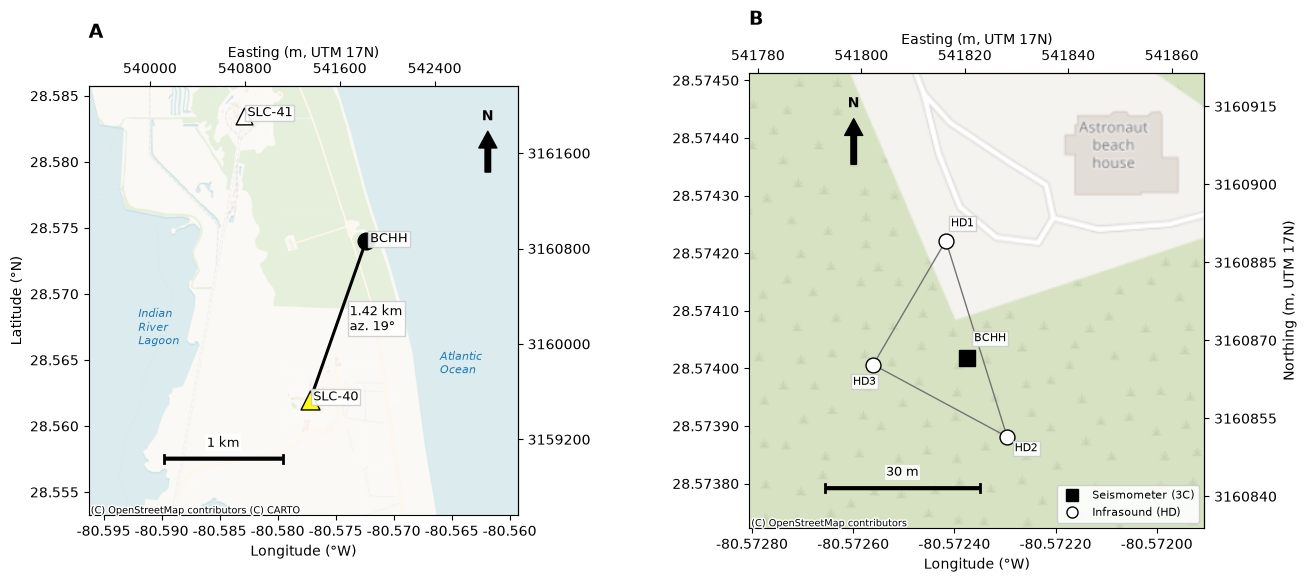

In [6]:
fig, axes = make_figure1(
    slc40=SLC40,
    slc41=SLC41,
    bchh=BCHH,
    bchh_sensors=BCHH_SENSORS,
    geod=GEOD,
    ll_to_utm=LL_TO_UTM,
    utm_to_ll=UTM_TO_LL,
)

plt.show()

## 7. Save publication outputs

The figure is written to both PNG and PDF. Change `OUTDIR` or `FIGURE_STEM` in the configuration cell rather than editing this cell.

In [7]:
output_paths = save_figure(
    fig=fig,
    output_directory=OUTDIR,
    filename_stem=FIGURE_STEM,
    extensions=("png", "pdf"),
    dpi=300,
)

for path in output_paths:
    print(path.resolve())

/Users/thompsong/Developer/KSCRocketSeismology/figures/fig01_slc40_bchh_location.png
/Users/thompsong/Developer/KSCRocketSeismology/figures/fig01_slc40_bchh_location.pdf


## Notes on reproducibility

- `KML_FILE` is the source of fixed launch-pad and camera coordinates.
- `STATIONXML_FILE` is the source of deployment-specific sensor positions.
- The time interval determines which StationXML epochs are selected.
- Easting and northing are derived from latitude and longitude using WGS84 / UTM zone 17N.
- The notebook contains no hardcoded BCHH sensor coordinates.
- KML and StationXML functions remain reusable outside this figure notebook.
- `figure1_utils.py` contains only Figure 1 plotting logic.
- Basemap appearance can change if the online tile provider updates its imagery or style.
